In [90]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import sys
import os
sys.path.append(os.path.abspath(".."))

%load_ext autoreload
%autoreload 2
import src.preprocessing as prep
import src.features as features

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Data

In [ ]:
data_dir = "../data/raw/PAMAP2_Dataset/Protocol/"
df = prep.load_all_subjects(data_dir)

Data loaded successfully from ../data/raw/PAMAP2_Dataset/Protocol/subject108.dat
DataFrame columns labeled successfully.
Data processed successfully.
Subject 0 data loaded and processed.
Data loaded successfully from ../data/raw/PAMAP2_Dataset/Protocol/subject109.dat
DataFrame columns labeled successfully.
Data processed successfully.
Subject 1 data loaded and processed.
Data loaded successfully from ../data/raw/PAMAP2_Dataset/Protocol/subject107.dat
DataFrame columns labeled successfully.
Data processed successfully.
Subject 2 data loaded and processed.
Data loaded successfully from ../data/raw/PAMAP2_Dataset/Protocol/subject106.dat
DataFrame columns labeled successfully.
Data processed successfully.
Subject 3 data loaded and processed.
Data loaded successfully from ../data/raw/PAMAP2_Dataset/Protocol/subject104.dat
DataFrame columns labeled successfully.
Data processed successfully.
Subject 4 data loaded and processed.
Data loaded successfully from ../data/raw/PAMAP2_Dataset/Protocol

In [78]:
df

,timestamp,activity,heart_rate,hand_temp,hand_acc1_x,hand_acc1_y,hand_acc1_z,hand_acc2_x,hand_acc2_y,hand_acc2_z,...,ankle_acc2_x,ankle_acc2_y,ankle_acc2_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,subject
0,67.36,1,84.0,33.8125,-9.64938,-1.68584,0.978888,-9.46791,-1.68076,1.15480,...,9.62143,-0.152332,-2.297230,-0.009174,-0.058976,0.001427,-34.9285,37.84290,-17.4803,0
1,67.47,1,84.0,33.8125,-9.42371,-1.64998,0.943660,-9.46841,-1.68082,1.09439,...,9.60659,-0.197655,-2.251600,0.055746,-0.003282,0.029691,-35.4566,38.38250,-18.0501,0
2,67.58,1,84.0,33.8125,-9.53788,-1.57357,0.903204,-9.45397,-1.69608,1.03401,...,9.59152,-0.137177,-2.266850,-0.038110,-0.004395,-0.006014,-34.6929,38.47320,-18.0476,0
3,67.69,1,84.0,33.8125,-9.53494,-1.72432,1.019220,-9.39256,-1.72657,1.20012,...,9.54653,-0.091793,-2.251620,0.029179,-0.031922,0.000206,-35.0621,37.97750,-17.7646,0
4,67.80,1,84.0,33.8125,-9.65366,-1.72478,0.863493,-9.45284,-1.71105,1.18505,...,9.56162,-0.061521,-2.236670,0.030197,-0.027046,0.003406,-35.0761,38.49230,-18.0489,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175493,2442.74,4,122.0,28.6875,-2.45242,10.29660,-1.994230,-2.38370,10.40740,-1.97459,...,9.32376,3.013710,1.765540,2.046050,0.147897,-0.698613,-21.0772,-8.92400,8.5653,8
175494,2442.85,4,122.0,28.6875,-2.90186,9.16494,-1.650760,-3.23772,8.96402,-1.71384,...,6.60552,2.838120,-5.257340,3.574080,-0.051112,-0.386876,-20.5655,-10.44580,13.8674,8
175495,2442.96,4,122.0,28.6875,-2.40659,9.73024,-1.645250,-2.53662,9.59354,-1.41392,...,8.25500,4.898860,-2.502980,-0.972910,0.007421,0.657275,-20.3344,-10.24960,15.1054,8
175496,2443.07,4,122.0,28.6875,-1.75992,10.90040,-1.754970,-2.04770,10.93360,-1.97609,...,10.66470,2.027690,-0.841671,-0.127264,-0.057552,0.961383,-21.0434,-8.33312,13.8938,8


### Save df

In [82]:
df.to_csv("../data/intermediate/pamap_cleaned_df.csv", index=False)

# Extract Features

In [ ]:
X , y, subjects = features.pull_features_per_subject(df)

In [81]:
X[subjects == 0]

,hand_temp_mean,hand_temp_std,hand_temp_min,hand_temp_max,hand_temp_rms,hand_acc1_x_mean,hand_acc1_x_std,hand_acc1_x_min,hand_acc1_x_max,hand_acc1_x_rms,...,ankle_mag_y_mean,ankle_mag_y_std,ankle_mag_y_min,ankle_mag_y_max,ankle_mag_y_rms,ankle_mag_z_mean,ankle_mag_z_std,ankle_mag_z_min,ankle_mag_z_max,ankle_mag_z_rms
0,33.846625,0.038925,33.7500,33.9375,33.846647,3.680423,5.508577,-11.76870,11.16540,6.624948,...,12.691234,12.093539,-10.08620,55.40840,17.530576,32.410179,16.920096,-18.75810,67.1017,36.561036
1,33.911000,0.036241,33.8125,34.0000,33.911019,6.483951,0.081159,6.22102,6.68359,6.484459,...,8.537133,0.380154,7.54392,9.57621,8.545593,37.912090,0.381655,36.37840,38.9339,37.914011
2,33.973625,0.035790,33.9375,34.0625,33.973644,6.479493,0.081124,6.26309,6.68359,6.480000,...,8.633401,0.378539,7.50172,9.82624,8.641696,37.868389,0.384355,36.37840,38.9330,37.870339
3,34.032500,0.031225,34.0000,34.0625,34.032514,6.470798,0.080327,6.22824,6.67957,6.471297,...,8.697743,0.379674,7.50172,9.86310,8.706026,37.862868,0.364468,36.94480,38.9322,37.864622
4,34.085750,0.032931,34.0000,34.1250,34.085766,6.460235,0.079081,6.22076,6.68492,6.460719,...,8.747021,0.359379,7.77086,9.86310,8.754400,37.846595,0.350338,37.08700,38.9322,37.848217
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,30.867875,0.024447,30.8125,30.9375,30.867885,-9.530674,13.771315,-54.04270,12.46190,16.747623,...,20.414532,21.228204,-25.86060,68.28190,29.451482,9.706468,12.404701,-21.37220,53.1514,15.750941
89,30.835000,0.030000,30.8125,30.8750,30.835015,-7.721476,13.724458,-46.62680,13.08740,15.747442,...,24.208118,20.592025,-25.86060,68.28190,31.781511,11.458803,11.884205,-19.82170,53.1514,16.508740
90,30.830625,0.028360,30.8125,30.8750,30.830638,-4.908149,11.621932,-56.28790,17.92900,12.615833,...,27.096679,14.617646,-31.60320,66.82730,30.788076,12.765020,11.590292,-19.82170,36.4121,17.241827
91,30.832250,0.029057,30.8125,30.8750,30.832264,-4.937121,8.530283,-56.28790,17.92900,9.856008,...,24.707190,11.162295,-31.60320,51.88050,27.111659,21.794862,11.010684,-12.87000,36.7261,24.418255


## Visualize Dataset

In [74]:
df_feat = X.copy()
df_feat["activity"] = y
df_feat["subject"] = subjects

In [ ]:
def plot_feature_by_activity(df_feat, feature, activity_label_mapping=pf.ACTIVITY_LABEL_MAPPING):
    plt.figure(figsize=(12, 6))
    df_plot = df_feat.copy()
    # map numeric → string labels
    df_plot["activity_name"] = df_plot["activity"].map(activity_label_mapping)

    sns.boxplot(
        data=df_plot,
        x="activity_name",
        y=feature
    )

    plt.title(f"{feature} by Activity")
    plt.xticks(rotation=45)
    plt.show()

def plot_feature_distribution(df_feat, feature):
    plt.figure(figsize=(12, 6))
    sns.histplot(df_feat[feature], kde=True)
    plt.title(f"Distribution of {feature}")
    plt.show()

def plot_subject_activity_distribution(df_feat, activity_label_mapping=pf.ACTIVITY_LABEL_MAPPING):
    plt.figure(figsize=(12, 6))
    df_plot = df_feat.copy()
    df_plot["activity_name"] = df_plot["activity"].map(activity_label_mapping)
    sns.countplot(data=df_plot, x="activity_name", hue="subject")
    plt.title("Activity Distribution by Subject")
    plt.xticks(rotation=45)
    plt.legend(title="Subject")
    plt.show() 

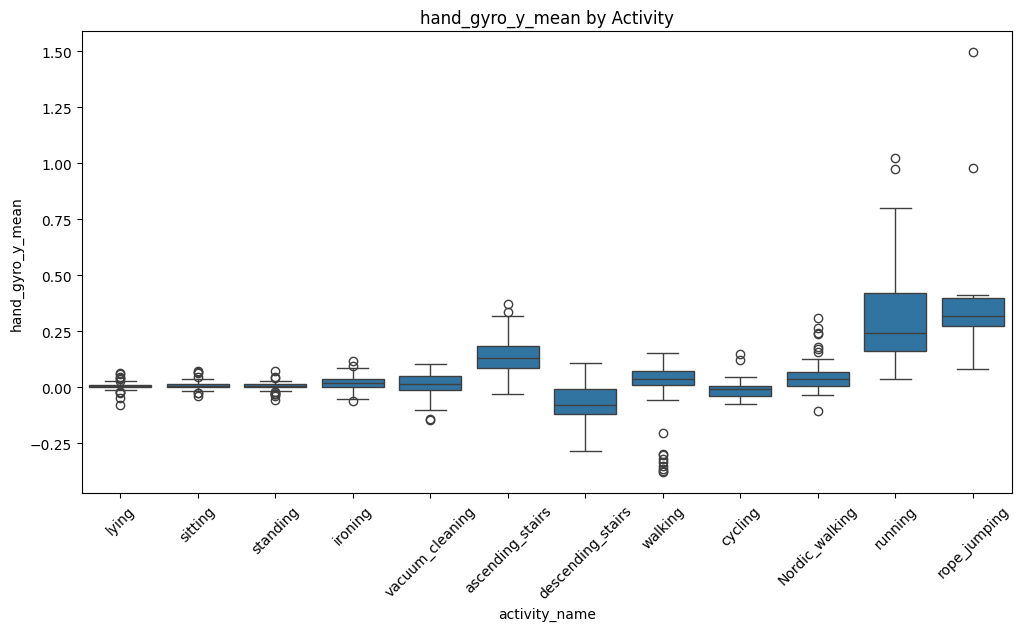

In [70]:
feature = df_feat.columns[40] 
plot_feature_by_activity(df_feat, feature)

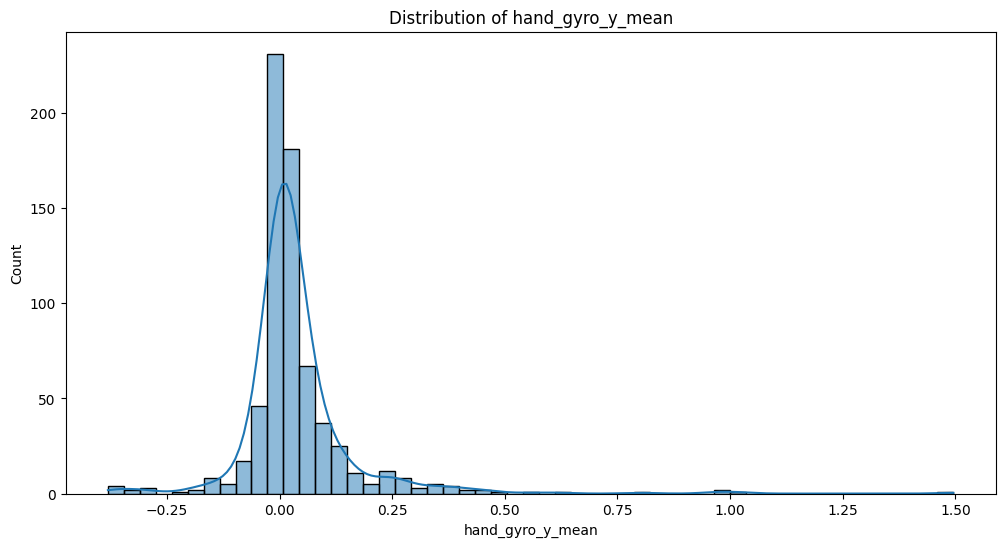

In [77]:
plot_feature_distribution(df_feat, feature)

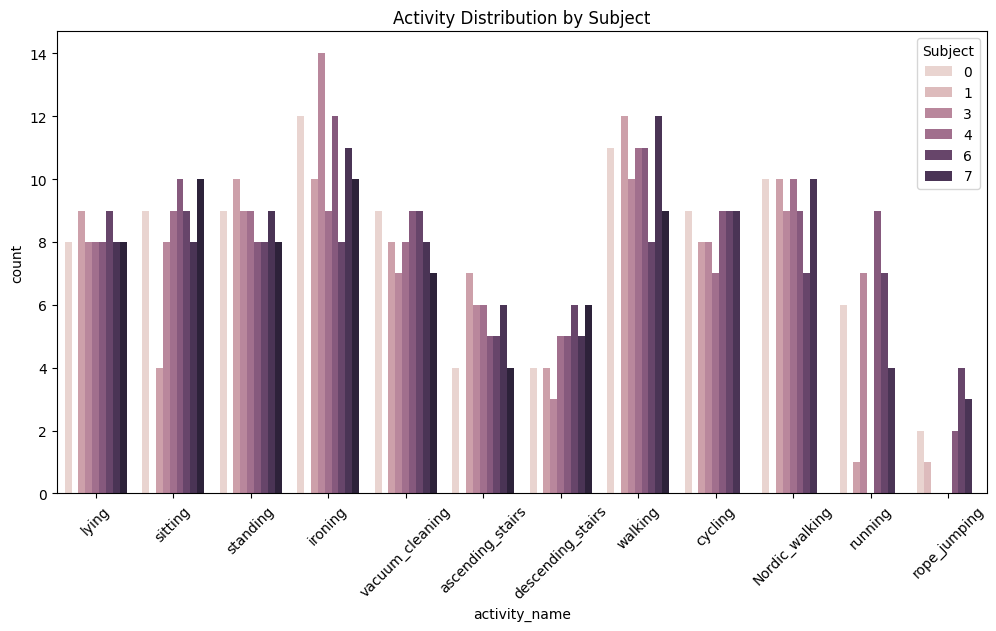

In [76]:
plot_subject_activity_distribution(df_feat)